# Mid Defence 1 — Colab Runner

This notebook contains only Google Drive setup, package extraction, configuration, execution, and result inspection.

Upload `md1_data_pipeline_code.zip` to:

```text
My Drive/ml_project/code/data_pipeline/md1_data_pipeline_code.zip
```

The notebook uses `My Drive/ml_project/code/data_pipeline` as the code workspace, extracts the implementation inside that folder, imports it from Google Drive, and writes the pipeline results and exports into subfolders there.


## 1. Runtime configuration

For the final defence data run, keep:

- `RUN_MODE = "real"`
- `MAX_MATCHES = None`

For a fast structural verification, use `RUN_MODE = "synthetic_demo"`.


In [1]:
# Edit only these values when necessary.
DRIVE_SUBFOLDER = "ml_project/code/data_pipeline"
CODE_ZIP_NAME = "md1_data_pipeline_code.zip"

RUN_MODE = "real"                 # "real" or "synthetic_demo"
MAX_MATCHES = None                # None = complete season in real mode
CUSTOM_RUN_NAME = None            # Optional string override
SHOW_PLOTS = True
FAIL_ON_READINESS = True
FORCE_REEXTRACT_CODE = False


## 2. Mount Google Drive and extract the implementation

In [2]:
import os
import shutil
import sys
import zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_MYDRIVE = Path("/content/drive/MyDrive")
else:
    # Local fallback for notebook verification outside Colab.
    DRIVE_MYDRIVE = Path(os.environ.get("MD1_LOCAL_ROOT", str(Path.cwd()))).resolve()

DRIVE_WORKSPACE = DRIVE_MYDRIVE / DRIVE_SUBFOLDER
# The requested Drive folder is the code root; no extra /code level is added.
CODE_ROOT = DRIVE_WORKSPACE
CODE_ZIP_PATH = CODE_ROOT / CODE_ZIP_NAME
EXTRACT_ROOT = CODE_ROOT / "extracted"
RESULTS_ROOT = DRIVE_WORKSPACE / "results"
EXPORTS_ROOT = DRIVE_WORKSPACE / "exports"

for folder in (DRIVE_WORKSPACE, CODE_ROOT, EXTRACT_ROOT, RESULTS_ROOT, EXPORTS_ROOT):
    folder.mkdir(parents=True, exist_ok=True)

if not CODE_ZIP_PATH.exists():
    raise FileNotFoundError(
        "Implementation ZIP not found. Upload it to:\n"
        f"{CODE_ZIP_PATH}\n"
        "Then rerun this cell."
    )

zip_stamp = f"{CODE_ZIP_PATH.stat().st_size}:{CODE_ZIP_PATH.stat().st_mtime_ns}"
stamp_path = EXTRACT_ROOT / ".source_zip_stamp"
previous_stamp = stamp_path.read_text(encoding="utf-8").strip() if stamp_path.exists() else ""

if FORCE_REEXTRACT_CODE or zip_stamp != previous_stamp:
    if EXTRACT_ROOT.exists():
        shutil.rmtree(EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(CODE_ZIP_PATH, "r") as archive:
        archive.extractall(EXTRACT_ROOT)
    stamp_path.write_text(zip_stamp, encoding="utf-8")
    print("Implementation extracted from the uploaded ZIP.")
else:
    print("Extracted implementation is current; reusing it.")

PACKAGE_ROOT = EXTRACT_ROOT / "md1_data_pipeline_code"
if not PACKAGE_ROOT.exists():
    # Supports a ZIP created without the optional top-level directory.
    PACKAGE_ROOT = EXTRACT_ROOT

print(f"Drive code workspace: {DRIVE_WORKSPACE}")
print(f"Implementation ZIP: {CODE_ZIP_PATH}")
print(f"Extracted package root: {PACKAGE_ROOT}")
print(f"Results root: {RESULTS_ROOT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Implementation extracted from the uploaded ZIP.
Drive code workspace: /content/drive/MyDrive/ml_project/code/data_pipeline
Implementation ZIP: /content/drive/MyDrive/ml_project/code/data_pipeline/md1_data_pipeline_code.zip
Extracted package root: /content/drive/MyDrive/ml_project/code/data_pipeline/extracted/md1_data_pipeline_code
Results root: /content/drive/MyDrive/ml_project/code/data_pipeline/results


## 3. Install dependencies and import the package

In [3]:
import subprocess
import importlib
import py_compile

requirements_path = PACKAGE_ROOT / "requirements_colab.txt"
if not requirements_path.exists():
    raise FileNotFoundError(f"Missing requirements file: {requirements_path}")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    "-r",
    str(requirements_path),
])

package_dir = PACKAGE_ROOT / "md1_data_pipeline"
for module_path in sorted(package_dir.glob("*.py")):
    py_compile.compile(str(module_path), doraise=True)

if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

# Remove an older in-memory import after re-extraction.
for module_name in list(sys.modules):
    if module_name == "md1_data_pipeline" or module_name.startswith("md1_data_pipeline."):
        del sys.modules[module_name]

from md1_data_pipeline import build_default_config, execute_complete_workflow
from md1_data_pipeline.core import read_json

print("Package import and syntax validation passed.")


Package import and syntax validation passed.


## 4. Resolve the run configuration

In [4]:
RUN_NAME, config = build_default_config(
    results_root=RESULTS_ROOT,
    run_mode=RUN_MODE,
    max_matches=MAX_MATCHES,
    run_name=CUSTOM_RUN_NAME,
)

print(f"Run mode: {RUN_MODE}")
print(f"Run name: {RUN_NAME}")
print(f"Output root: {config.project_root}")
print(f"Maximum matches: {config.max_matches}")
config


Run mode: real
Run name: Premier_League_2015_16_DATA_ONLY_FULL_REAL
Output root: /content/drive/MyDrive/ml_project/code/data_pipeline/results/Premier_League_2015_16_DATA_ONLY_FULL_REAL
Maximum matches: None


MD1Config(project_root=PosixPath('/content/drive/MyDrive/ml_project/code/data_pipeline/results/Premier_League_2015_16_DATA_ONLY_FULL_REAL'), data_mode='real', competition_id=2, season_id=27, competition_name='Premier League', season_name='2015/2016', football_data_code='1516', football_data_division='E0', max_matches=None, date_tolerance_days=1, train_fraction=0.65, validation_fraction=0.2, snapshot_minutes=(0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90), rolling_windows=(3, 5, 10), overwrite_downloads=False, download_360=True, download_workers=6, random_seed=42)

## 5. Execute the complete workflow

The first real run downloads the season data. Later runs reuse the cached files in Google Drive.


Downloading/reusing 1,140 match files for 380 matches with 6 worker(s).
Match files completed: 100/1,140
Match files completed: 200/1,140
Match files completed: 300/1,140
Match files completed: 400/1,140
Match files completed: 500/1,140
Match files completed: 600/1,140
Match files completed: 700/1,140
Match files completed: 800/1,140
Match files completed: 900/1,140
Match files completed: 1,000/1,140
Match files completed: 1,100/1,140
Match files completed: 1,140/1,140
Dataset download/cache stage completed successfully.
Normalized 50/380 matches
Normalized 100/380 matches
Normalized 150/380 matches
Normalized 200/380 matches
Normalized 250/380 matches
Normalized 300/380 matches
Normalized 350/380 matches
Built snapshots for 50/380 matches
Built snapshots for 100/380 matches
Built snapshots for 150/380 matches
Built snapshots for 200/380 matches
Built snapshots for 250/380 matches
Built snapshots for 300/380 matches
Built snapshots for 350/380 matches


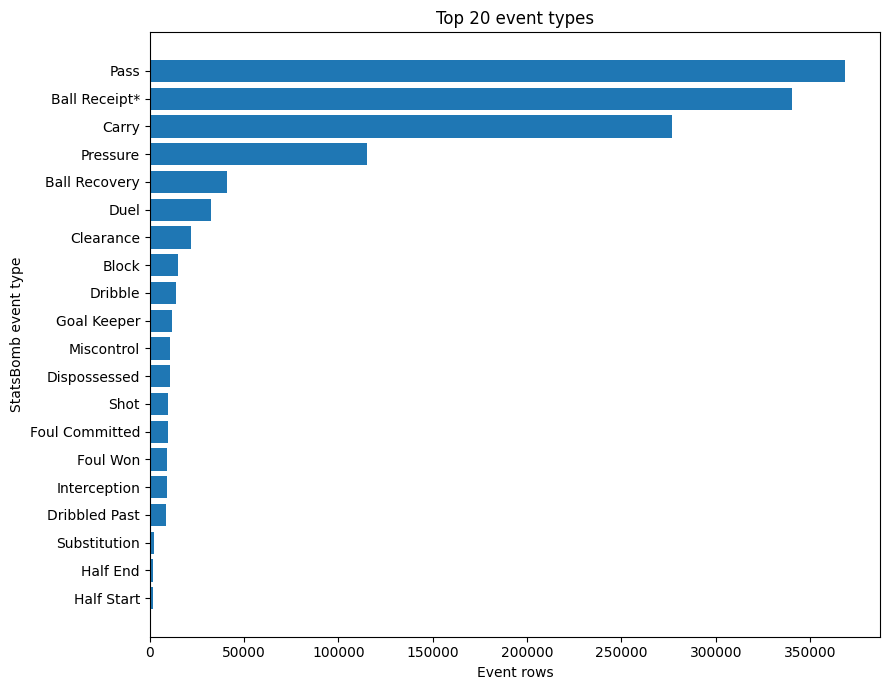

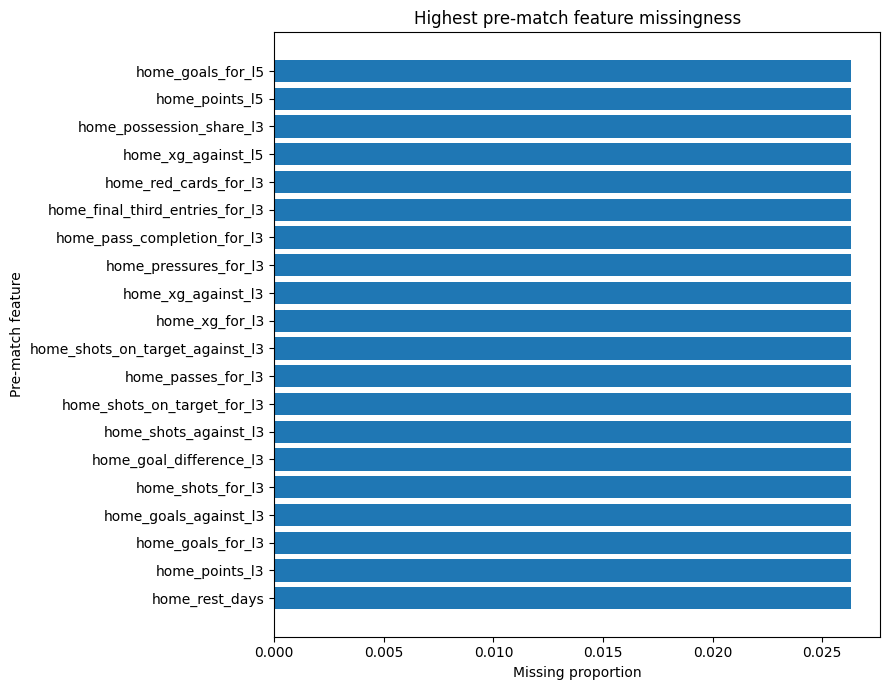

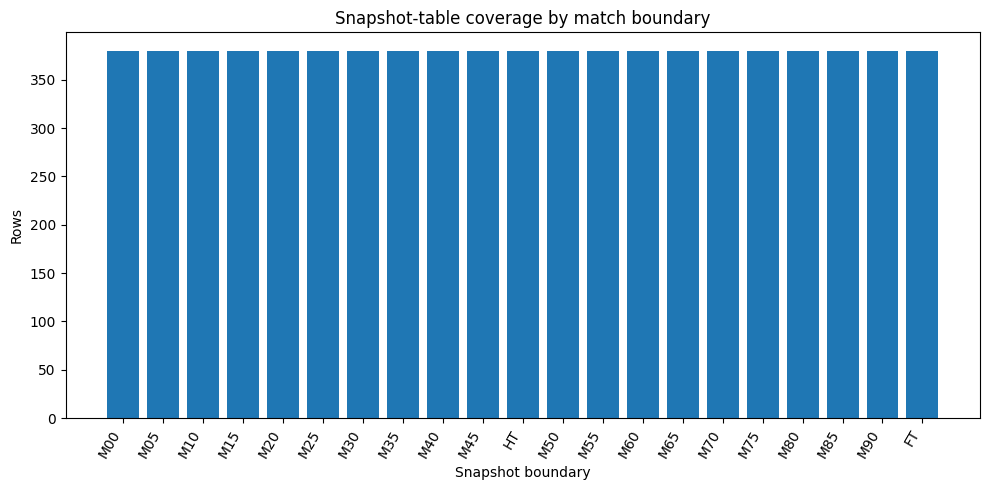

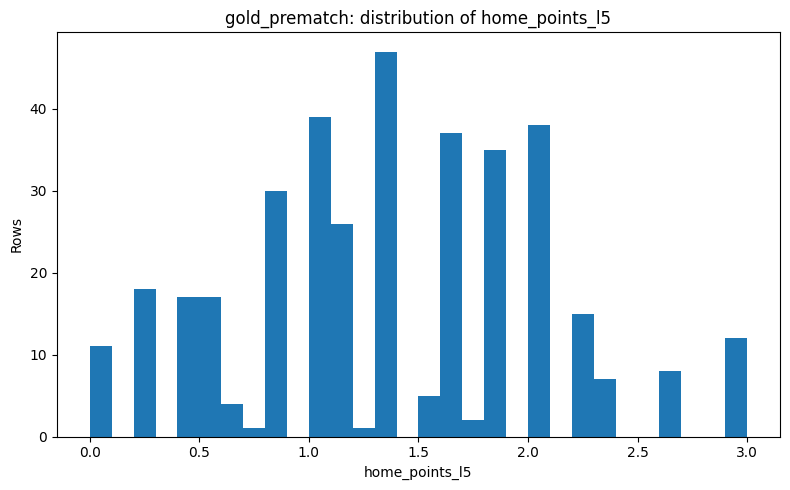

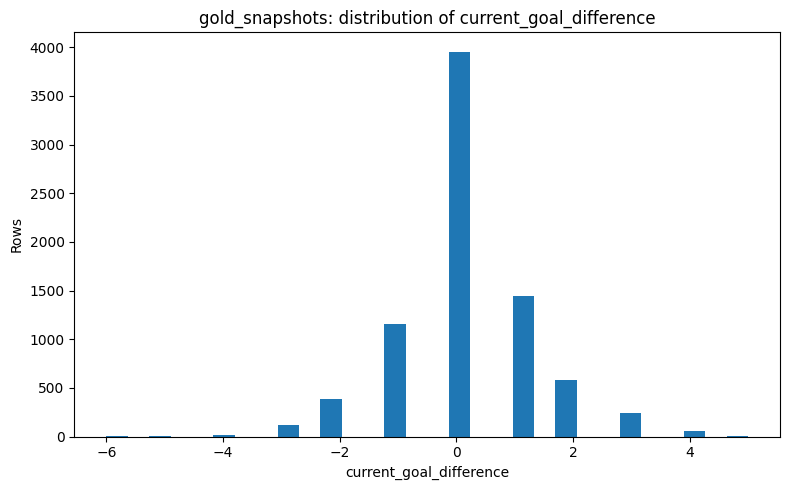

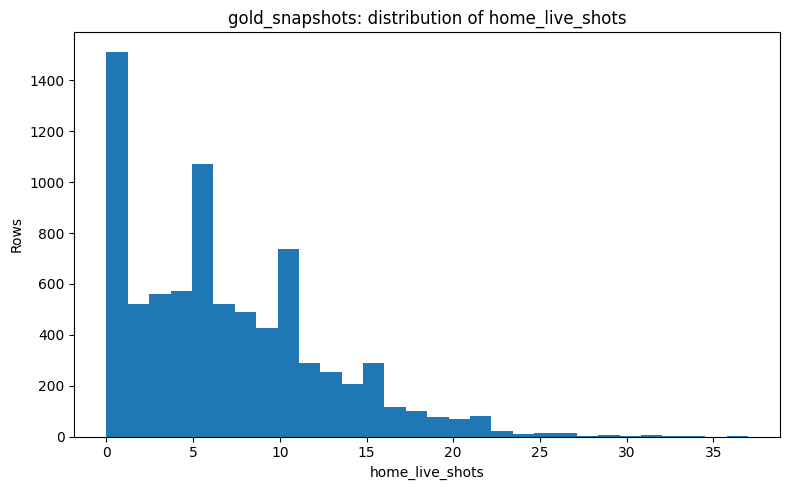

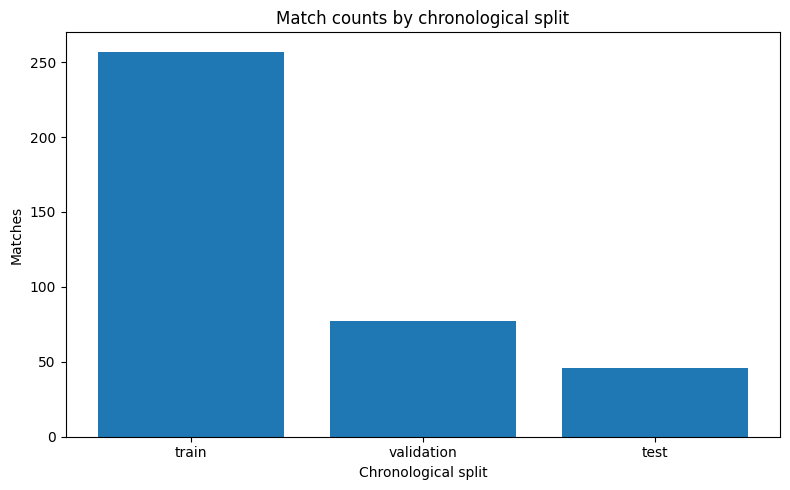

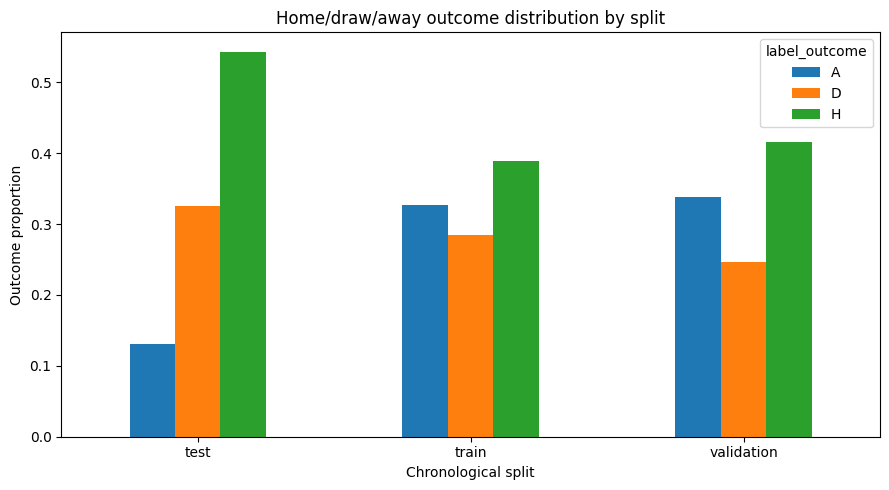

Completed in 8.2 minutes.
Evidence root: /content/drive/MyDrive/ml_project/code/data_pipeline/results/Premier_League_2015_16_DATA_ONLY_FULL_REAL


In [5]:
workflow = execute_complete_workflow(
    config=config,
    workspace_root=DRIVE_WORKSPACE,
    exports_root=EXPORTS_ROOT,
    run_name=RUN_NAME,
    show_plots=SHOW_PLOTS,
    fail_on_readiness=FAIL_ON_READINESS,
)

result = workflow["result"]
print(f"Completed in {workflow['elapsed_minutes']:.1f} minutes.")
print(f"Evidence root: {config.project_root}")


## 6. Headline results

In [6]:
import pandas as pd
from IPython.display import display

summary = read_json(result["summary_path"])
display(pd.Series(summary, name="value").to_frame())

print("Row counts")
display(result["row_counts"])

print("Chronological split summary")
display(workflow["report_tables"]["split_summary"])

print("Class distribution")
display(workflow["report_tables"]["class_distribution"])


,value
data_mode,real
competition,Premier League
season,2015/2016
competition_id,2
season_id,27
matches,380
event_rows,1313773
lineup_rows,15926
matches_with_360,0
gold_prematch_rows,380


Row counts


,table,rows,columns,partitions
0,competitions,1,12.0,NaN
1,matches,380,28.0,NaN
2,teams,20,3.0,NaN
3,players,644,5.0,NaN
4,lineups,15926,17.0,NaN
5,match_event_facts,760,16.0,NaN
6,event_manifest,380,12.0,NaN
7,coverage_360,380,4.0,NaN
8,team_match_facts,760,25.0,NaN
9,gold_prematch,380,178.0,NaN


Chronological split summary


,split,matches,start,end
0,train,257,2015-08-08 13:45:00,2016-02-13 18:30:00
1,validation,77,2016-02-14 11:00:00,2016-04-18 21:00:00
2,test,46,2016-04-19 20:45:00,2016-05-17 21:00:00


Class distribution


,split,label_outcome,matches,proportion_within_split
0,test,A,6,0.130435
1,test,D,15,0.326087
2,test,H,25,0.543478
3,train,A,84,0.326848
4,train,D,73,0.284047
5,train,H,100,0.389105
6,validation,A,26,0.337662
7,validation,D,19,0.246753
8,validation,H,32,0.415584


## 7. Integrity, leakage, odds, and boundary evidence

In [7]:
print("Key and foreign-key audit")
display(result["key_audit"])

print("Leakage and integrity tests")
display(result["leakage_tests"])

print("Odds coverage")
display(result["odds_coverage"])
display(result["join_map"].head(12))

print("Half-time and full-time boundary walkthrough")
snapshot_audit = result["snapshot_audit_sample"]
display(snapshot_audit[
    snapshot_audit["snapshot_id"].isin(["M40", "M45", "HT", "M50", "M90", "FT"])
])

print("Event partition foreign-key and ordering audit")
display(pd.read_csv(config.audit_root / "event_partition_contract_audit.csv").head())

print("Starting-lineup audit")
display(pd.read_csv(config.audit_root / "starting_lineup_audit.csv").head())


Key and foreign-key audit


,check,passed,details
0,matches.match_id unique,True,duplicates=0
1,match team foreign keys valid,True,teams=20
2,one event partition per match,True,"partitions=380, matches=380"
3,event IDs unique within each match,True,failures=0
4,event indices unique within each match,True,failures=0
5,"event partitions, foreign keys, and chronology...",True,failed_matches=0
6,event-derived score reconciles with match meta...,True,failures=0
7,lineup match foreign keys valid,True,invalid=0
8,lineup team foreign keys valid,True,teams=20
9,lineup player foreign keys valid,True,players=644


Leakage and integrity tests


,test,passed,details,seconds
0,pre-match source time contract,True,all max_source_finish values are before target...,0.002264
1,snapshot cutoff contract,True,all used event orders are at or before cutoff;...,0.020081
2,chronological split contract,True,strict train < validation < test chronology,0.002147
3,target-match perturbation test,True,8 target team-match rows unchanged after each ...,3.879097
4,multi-match future-event perturbation test,True,6 early snapshots across 3 matches unchanged a...,3.405120
5,half-time boundary test,True,HT includes period-1 stoppage and excludes per...,0.020291
6,strict M90 versus full-time boundary test,True,M90 excludes a 90:30 stoppage event; FT includ...,0.019371
7,raw and clipped goal-margin contract,True,raw margins preserve observed scores; modeling...,0.008954
8,full foreign-key and event-order contract,True,all foreign-key and event-order contracts pass...,0.006893
9,canonical own-goal counting,True,Shot Goal and Own Goal For count; paired Own G...,0.000007


Odds coverage


...

,match_id,snapshot_id,snapshot_kind,snapshot_minute,split,snapshot_cutoff_event_order,max_used_event_order,next_excluded_event_order,max_used_period,max_used_minute,...,final_away_score,label_margin_raw,label_margin,home_live_red_cards,away_live_red_cards,man_advantage_home,home_live_shots,away_live_shots,home_live_xg,away_live_xg
7022,3754206,M40,strict_minute,40,test,1685,1685,1686.0,1,39,...,1,0,0,0,0,0,3,2,0.274924,0.208045
7023,3754206,M45,strict_minute,45,test,1830,1830,1831.0,1,45,...,1,0,0,0,0,0,3,2,0.274924,0.208045
7024,3754206,HT,half_time_boundary,45,test,1863,1863,1864.0,1,46,...,1,0,0,0,0,0,3,2,0.274924,0.208045
7025,3754206,M50,strict_minute,50,test,2058,2058,2059.0,2,49,...,1,0,0,0,0,0,3,2,0.274924,0.208045
7033,3754206,M90,strict_minute,90,test,3537,3537,3538.0,2,88,...,1,0,0,0,0,0,5,10,0.602450,0.678389
7034,3754206,FT,full_time_boundary,90,test,3681,3681,NaN,2,95,...,1,0,0,0,0,0,5,10,0.602450,0.678389


Event partition foreign-key and ordering audit


,match_id,partition_match_fk_valid,event_team_fk_valid,possession_team_fk_valid,event_player_fk_valid,event_order_contiguous,event_chronological_order_valid,event_rows,invalid_event_teams,invalid_possession_teams,invalid_event_players
0,3753972,True,True,True,True,True,True,3683,0,0,0
1,3753973,True,True,True,True,True,True,3478,0,0,0
2,3753974,True,True,True,True,True,True,3562,0,0,0
3,3753975,True,True,True,True,True,True,3769,0,0,0
4,3753976,True,True,True,True,True,True,3939,0,0,0


Starting-lineup audit


,match_id,team_id,unique_starters
0,3753972,26,11
1,3753972,28,11
2,3753973,33,11
3,3753973,40,11
4,3753974,29,11


## 8. Data-readiness gate

In [8]:
readiness = workflow["readiness"]
display(readiness)

failed = readiness.loc[~readiness["passed"]]
if failed.empty:
    print("All Mid Defence 1 data checks passed.")
else:
    print("Failed readiness checks:")
    display(failed)


,check,passed,details
0,real full-season mode,True,"mode=real, max_matches=None; required for real..."
1,complete Premier League season,True,matches=380; 380 required for real defence run
2,all key and foreign-key checks pass,True,failed=0
3,event scores reconcile with match metadata,True,failed_matches=0
4,all leakage and integrity tests pass,True,passed=12/12
5,one pre-match row per match,True,"prematch=380, matches=380"
6,consistent snapshot coverage per match,True,snapshots_per_match=[21]
7,strict M90 and full-time snapshots both exist,True,"boundaries=['FT', 'HT', 'M00', 'M05', 'M10', '..."
8,snapshot rows inherit match-level split,True,each match has exactly one split
9,provider and odds-audit fields are excluded fr...,True,"administrative/provider fields are metadata, a..."


All Mid Defence 1 data checks passed.


## 9. Generated files

In [9]:
exports = workflow["exports"]

print(f"Google Drive code workspace: {DRIVE_WORKSPACE}")
print(f"Full result folder: {config.project_root}")
print(f"Results index: {exports['results_index_path']}")
print(f"Evidence ZIP: {exports['archive_path']}")
print(f"Latest summary: {exports['latest_summary_path']}")
print(f"Plots: {workflow['profile_paths']['plots_root']}")

print("\nStart with DATA_RESULTS_INDEX.md in the Drive workspace.")


Google Drive code workspace: /content/drive/MyDrive/ml_project/code/data_pipeline
Full result folder: /content/drive/MyDrive/ml_project/code/data_pipeline/results/Premier_League_2015_16_DATA_ONLY_FULL_REAL
Results index: /content/drive/MyDrive/ml_project/code/data_pipeline/DATA_RESULTS_INDEX.md
Evidence ZIP: /content/drive/MyDrive/ml_project/code/data_pipeline/exports/Mid_Defence_1_Data_Evidence_Premier_League_2015_16_DATA_ONLY_FULL_REAL.zip
Latest summary: /content/drive/MyDrive/ml_project/code/data_pipeline/LATEST_DATA_RUN_SUMMARY.json
Plots: /content/drive/MyDrive/ml_project/code/data_pipeline/results/Premier_League_2015_16_DATA_ONLY_FULL_REAL/audit/plots

Start with DATA_RESULTS_INDEX.md in the Drive workspace.
